# Syllable Transition Probabilities

Computes **38×38 transition probability matrices** from MoSeq frame-level label sequences, where each entry T[i,j] is the probability that a mouse transitions from syllable i to syllable j on the next frame. These matrices capture the sequential structure of behavior beyond simple usage frequencies.

**Two targeted analyses:**
- **CS mice** — P(transitioning into motor deficit syllables), i.e., Low Velocity, High Displacement (LVHD) cluster
- **WMS mice** — P(transitioning into cognitive deficit syllables), i.e., Low Velocity, Low Displacement (LVLD) cluster

Each analysis is split by age cohort (young, aged) and sex to assess whether stroke-induced behavioral biases differ across groups.

In [ ]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
try:
    from statannotations.Annotator import Annotator
except:
    !pip install statannotations
    from statannotations.Annotator import Annotator
import matplotlib.pyplot as plt
from collections import defaultdict

In [ ]:
MODEL_PATH = Path('/mnt/g/Shared drives/llorente-lab/Moseq/AnalyzedData/Nature_Comms_Manuscript/')
MOSEQ_DF_PATH = MODEL_PATH / 'moseq_df.csv'
STATS_DF_PATH = MODEL_PATH / 'stats_df.csv'

moseq_df = pd.read_csv(MOSEQ_DF_PATH)
stats_df = pd.read_csv(STATS_DF_PATH)

print(moseq_df.shape)
print(stats_df.shape)

/home/llorente/[/home/llorente/miniconda3new]/envs/moseq2-new/lib/python3.7/site-packages/IPython/core/interactiveshell.py:3063: DtypeWarning: Columns (31,32) have mixed types.Specify dtype option on import or set low_memory=False.
  interactivity=interactivity, compiler=compiler, result=result)


(20241328, 37)
(26976, 95)


In [ ]:
save_path = '/mnt/g/Shared drives/llorente-lab/Moseq/Manuscript/revision_resubmission/figures_revision_plots/Figures_supplementary'
os.makedirs(save_path, exist_ok=True)
SAVE_PATH = Path(save_path)

## Setup & Data Loading

Loads the MoSeq frame-level dataset (20M+ rows) and stats summary. Defines color palettes for all 8 age × sex × treatment groups and creates the `age_sex` composite label.

In [ ]:
# Step 2: define palettes
palette_4 = {
    'CS_YM': '#E69F00',
    'CS_AM': '#D55E00',
    'WMS_YM': '#56B4E9',
    'WMS_AM': '#0072B2',
}

palette_females = {
    'CS_YF': '#FFCC80',   # light orange
    'CS_AF': '#7B2D00',   # deep orange
    'WMS_YF': '#90CAF9',  # light blue
    'WMS_AF': '#00838F',  # tealish
}

# combined palette keyed by (treatment, age_sex)
full_palette = {**palette_4, **palette_females}

In [ ]:
full_palette

{'CS_YM': '#E69F00',
 'CS_AM': '#D55E00',
 'WMS_YM': '#56B4E9',
 'WMS_AM': '#0072B2',
 'CS_YF': '#FFCC80',
 'CS_AF': '#7B2D00',
 'WMS_YF': '#90CAF9',
 'WMS_AF': '#00838F'}

In [ ]:
moseq_df = moseq_df[moseq_df['labels (usage sort)'] >= 0]
moseq_df.shape # make sure it's all okay

(20239642, 37)

In [ ]:
moseq_df['age_sex'] = moseq_df['age'] + ' ' + moseq_df['sex']

In [ ]:
moseq_df['age_sex'].unique()

array(['young Male', 'aged Male', 'young Female', 'aged Female'],
      dtype=object)

## Transition Matrix Computation

`compute_transition_matrix()` takes a sequence of syllable labels for one mouse and returns a row-normalized 38×38 matrix: T[i,j] = count(i→j) / count(i→anything). Computed independently per mouse per timepoint (562 mice total), then averaged within groups to yield 34 group-level matrices.

A flat (1,444-feature) version is also stored in `transition_feature_df` for potential downstream ML use.

In [ ]:
import numpy as np
import pandas as pd
from collections import defaultdict

def compute_transition_matrix(label_sequence, n_syllables=None):
    labels = np.array(label_sequence)

    if n_syllables is None:
        n_syllables = int(labels.max()) + 1

    T_counts = np.zeros((n_syllables, n_syllables), dtype=np.float64)

    # Consecutive pairs: (labels[t], labels[t+1])
    from_labels = labels[:-1]
    to_labels   = labels[1:]

    # Vectorized count accumulation
    np.add.at(T_counts, (from_labels, to_labels), 1)

    # Row-normalize (rows with zero transitions -> zero row, avoids NaN)
    row_sums = T_counts.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1  # avoid division by zero
    T = T_counts / row_sums

    return T

In [ ]:
n_syllables = 38

# Filter moseq_df to only include syllables 0–37
moseq_df_filtered = moseq_df[
    (moseq_df['labels (usage sort)'] >= 0) &
    (moseq_df['labels (usage sort)'] <= 37)
]

print(f"Number of syllables: {n_syllables} (labels 0–37 inclusive)")

In [ ]:
mouse_transition_matrices = {}   # uuid -> T (n_syllables x n_syllables)
mouse_metadata = {}              # uuid -> {group, treatment, timepoint, sex, age, age_sex}

meta_cols = ['group', 'treatment', 'timepoint', 'sex', 'age', 'age_sex']

for uuid, mouse_df in moseq_df_filtered.groupby('uuid'):
    # Sort by session then frame index to preserve temporal order
    mouse_df = mouse_df.sort_values(['SessionName', 'frame index'])

    labels = mouse_df['labels (usage sort)'].values.astype(int)

    T = compute_transition_matrix(labels, n_syllables=n_syllables)
    mouse_transition_matrices[uuid] = T

    # Store metadata (take first row — same for all rows of a given mouse)
    mouse_metadata[uuid] = {
        col: mouse_df[col].iloc[0] for col in meta_cols if col in mouse_df.columns
    }

print(f"Computed transition matrices for {len(mouse_transition_matrices)} mice.")
print(f"Matrix shape per mouse: {next(iter(mouse_transition_matrices.values())).shape}")

Computed transition matrices for 562 mice.
Matrix shape per mouse: (38, 38)


In [ ]:
group_matrices = defaultdict(list)

for uuid, T in mouse_transition_matrices.items():
    grp = mouse_metadata[uuid].get('group', 'unknown')
    group_matrices[grp].append(T)

group_avg_matrices = {
    grp: np.mean(np.stack(matrices, axis=0), axis=0)
    for grp, matrices in group_matrices.items()
}

for grp, T_avg in group_avg_matrices.items():
    n = len(group_matrices[grp])
    print(f"  Group '{grp}': averaged over {n} mice | T shape: {T_avg.shape}")

  Group 'CS_YF_BSL': averaged over 11 mice | T shape: (38, 38)
  Group 'WMS_YF_BSL': averaged over 16 mice | T shape: (38, 38)
  Group 'WMS_AF_BSL': averaged over 14 mice | T shape: (38, 38)
  Group 'CTRL_YF_BSL': averaged over 15 mice | T shape: (38, 38)
  Group 'CS_AF_30DPI': averaged over 10 mice | T shape: (38, 38)
  Group 'CTRL_AM_BSL': averaged over 19 mice | T shape: (38, 38)
  Group 'WMS_YF_7DPI': averaged over 14 mice | T shape: (38, 38)
  Group 'CTRL_AF_30DPI': averaged over 15 mice | T shape: (38, 38)
  Group 'CS_AF_BSL': averaged over 12 mice | T shape: (38, 38)
  Group 'CS_AF_7DPI': averaged over 9 mice | T shape: (38, 38)
  Group 'CTRL_YM_30DPI': averaged over 27 mice | T shape: (38, 38)
  Group 'CTRL_YM_7DPI': averaged over 27 mice | T shape: (38, 38)
  Group 'CS_YM_30DPI': averaged over 23 mice | T shape: (38, 38)
  Group 'WMS_AM_BSL': averaged over 16 mice | T shape: (38, 38)
  Group 'CS_YF_30DPI': averaged over 16 mice | T shape: (38, 38)
  Group 'CS_YF_7DPI': average

In [ ]:
records = []
for uuid, T in mouse_transition_matrices.items():
    row = {'uuid': uuid}
    row.update(mouse_metadata[uuid])
    # T flattened: feature named "T_i_j"
    for i in range(n_syllables):
        for j in range(n_syllables):
            row[f'T_{i}_{j}'] = T[i, j]
    records.append(row)

transition_feature_df = pd.DataFrame(records)
print(f"\ntransition_feature_df shape: {transition_feature_df.shape}")
print(transition_feature_df.iloc[:, :10].head())


transition_feature_df shape: (562, 1451)
                                   uuid        group treatment timepoint  \
0  000ac955-e717-4dfd-acff-cf598a48c533    CS_YF_BSL        CS       BSL   
1  007a77ca-afe7-4a9d-9f3b-8faad2abd261   WMS_YF_BSL       WMS       BSL   
2  00c0414c-65c6-44c1-b90f-940c357303ab   WMS_AF_BSL       WMS       BSL   
3  015c2295-27d1-4f21-aed4-6a4229d2dd7b  CTRL_YF_BSL      CTRL       BSL   
4  015f81b7-631d-4bf9-8eee-8d0b4478f940  CS_AF_30DPI        CS     30DPI   

      sex    age       age_sex     T_0_0  T_0_1     T_0_2  
0  Female  young  young Female  0.831867    0.0  0.003910  
1  Female  young  young Female  0.852747    0.0  0.014286  
2  Female   aged   aged Female  0.848049    0.0  0.014374  
3  Female  young  young Female  0.827114    0.0  0.018657  
4  Female   aged   aged Female  0.836036    0.0  0.010811  


### Syllable-to-Cluster Mapping

Each syllable (0–37) is mapped to one of four kinematic clusters via `id_to_cluster`: High/Low Velocity × High/Low Displacement. This mapping is used to aggregate transition probabilities across syllables belonging to the same deficit cluster.

In [ ]:
id_to_cluster = {
    0:  'High Vel, High Disp',
    1:  'Low Vel, High Disp',
    2:  'Low Vel, Low Disp',
    3:  'High Vel, Low Disp',
    4:  'High Vel, Low Disp',
    5:  'Low Vel, Low Disp',
    6:  'High Vel, High Disp',
    7:  'Low Vel, High Disp',
    8:  'Low Vel, High Disp',
    9:  'Low Vel, High Disp',
    10: 'Low Vel, High Disp',
    11: 'Low Vel, Low Disp',
    12: 'High Vel, Low Disp',
    13: 'High Vel, Low Disp',
    14: 'Low Vel, Low Disp',
    15: 'High Vel, Low Disp',
    16: 'High Vel, High Disp',
    17: 'Low Vel, High Disp',
    18: 'High Vel, High Disp',
    19: 'Low Vel, High Disp',
    20: 'High Vel, High Disp',
    21: 'High Vel, High Disp',
    22: 'Low Vel, High Disp',
    23: 'High Vel, Low Disp',
    24: 'Low Vel, Low Disp',
    25: 'High Vel, High Disp',
    26: 'High Vel, High Disp',
    27: 'Low Vel, Low Disp',
    28: 'High Vel, High Disp',
    29: 'High Vel, High Disp',
    30: 'Low Vel, Low Disp',
    31: 'Low Vel, Low Disp',
    32: 'High Vel, High Disp',
    33: 'Low Vel, Low Disp',
    34: 'High Vel, Low Disp',
    35: 'High Vel, Low Disp',
    36: 'Low Vel, High Disp',
    37: 'Low Vel, Low Disp',
}

In [ ]:
cluster_to_ids = defaultdict(list)
for syl_id, cluster_name in id_to_cluster.items():
    cluster_to_ids[cluster_name].append(syl_id)

cluster_names = ['High Vel, High Disp', 'High Vel, Low Disp',
                 'Low Vel, High Disp',  'Low Vel, Low Disp']

# Syllable-level cluster index (0–3) for matrix reordering/coloring
cluster_name_to_idx = {name: i for i, name in enumerate(cluster_names)}
syl_to_cluster_idx  = np.array([cluster_name_to_idx[id_to_cluster[i]] for i in range(38)])

print("Syllable → cluster index:", syl_to_cluster_idx)

Syllable → cluster index: [0 2 3 1 1 3 0 2 2 2 2 3 1 1 3 1 0 2 0 2 0 0 2 1 3 0 0 3 0 0 3 3 0 3 1 1 2
 3]


In [ ]:
for col in ['treatment', 'timepoint']:
    print(moseq_df[col].unique())

['WMS' 'CTRL' 'CS']
['BSL' '30DPI' '7DPI']


In [ ]:
meta_cols = ['uuid', 'treatment', 'timepoint', 'sex', 'age']

mouse_meta_df = (moseq_df[meta_cols]
                 .drop_duplicates(subset='uuid')
                 .set_index('uuid'))

In [ ]:
mouse_meta_df['sex'].unique()

array(['Male', 'Female'], dtype=object)

# Comparisons

## Deficit-Specific Transition Probability Comparisons

For each deficit type, the transition probability is computed as the **sum of outgoing transition probabilities from any syllable into the target cluster**, averaged across all source syllables. This scalar per-animal per-timepoint value is compared across sex and timepoint within each treatment.

## P(transitioning into motor deficit)

**Motor deficit proxy:** P(next syllable ∈ LVHD cluster) in CS-treated mice. LVHD (Low Velocity, High Displacement) syllables are associated with impaired locomotor control following cortical stroke. Plotted separately for young and aged cohorts.

In [ ]:
records = []

for uuid, T in mouse_transition_matrices.items():
    if uuid not in mouse_meta_df.index:
        continue
    meta = mouse_meta_df.loc[uuid]

    if meta['treatment'] != 'CS':
        continue
    if meta['age'] not in ('young', 'aged'):
        continue
    if meta['sex'] not in ('Male', 'Female'):
        continue

    sub_matrix = T[np.ix_(non_lvhd_syllables, lvhd_syllables)]
    p_scalar   = sub_matrix.sum(axis=1).mean()

    # group = age_sex combination
    age_tag = 'Y' if meta['age'] == 'young' else 'A'
    sex_tag = 'M' if meta['sex'] == 'Male'  else 'F'
    group   = f'CS_{age_tag}{sex_tag}'  # CS_YM, CS_YF, CS_AM, CS_AF

    records.append({
        'uuid':      uuid,
        'timepoint': meta['timepoint'],
        'sex':       meta['sex'],
        'age':       meta['age'],
        'p_lvhd':    p_scalar,
        'group':     group,
    })

plot_df = pd.DataFrame(records)
print(plot_df.shape)
print(plot_df['group'].value_counts())
print(plot_df['timepoint'].value_counts())

(186, 6)
CS_YM    68
CS_AM    45
CS_YF    42
CS_AF    31
Name: group, dtype: int64
BSL      64
30DPI    63
7DPI     59
Name: timepoint, dtype: int64


### Plot young

In [ ]:
plot_df_young = plot_df[plot_df['age'] == 'young']
plot_df_young.shape

(110, 6)

In [ ]:
timepoint_order = ['BSL', '7DPI', '30DPI']
plot_df_young['timepoint'] = pd.Categorical(plot_df_young['timepoint'],categories=timepoint_order, ordered=True)
plot_df_young = plot_df_young.sort_values('timepoint')

/home/llorente/[/home/llorente/miniconda3new]/envs/moseq2-new/lib/python3.7/site-packages/ipykernel_launcher.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  


In [ ]:
plot_df_young.columns

Index(['uuid', 'timepoint', 'sex', 'age', 'p_lvhd', 'group'], dtype='object')

In [ ]:
def remove_outliers_iqr(df, value_col, group_cols):
    """Remove outliers using 1.5×IQR rule within each group."""
    mask = pd.Series(True, index=df.index)
    for keys, grp in df.groupby(group_cols):
        Q1  = grp[value_col].quantile(0.25)
        Q3  = grp[value_col].quantile(0.75)
        IQR = Q3 - Q1
        lo, hi = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
        outlier_idx = grp[(grp[value_col] < lo) | (grp[value_col] > hi)].index
        mask[outlier_idx] = False
    return df[mask]

z = len(plot_df_young)
print(f"Before: {z} rows")
plot_df_young = remove_outliers_iqr(plot_df_young, 'p_lvhd', ['group', 'timepoint'])
print(f"After:  {len(plot_df_young)} rows")
print(f"Removed: {len(plot_df_young) - z} outliers")

Before: 110 rows
After:  104 rows
Removed: -6 outliers


In [ ]:
plot_df_clean = plot_df_young.copy()

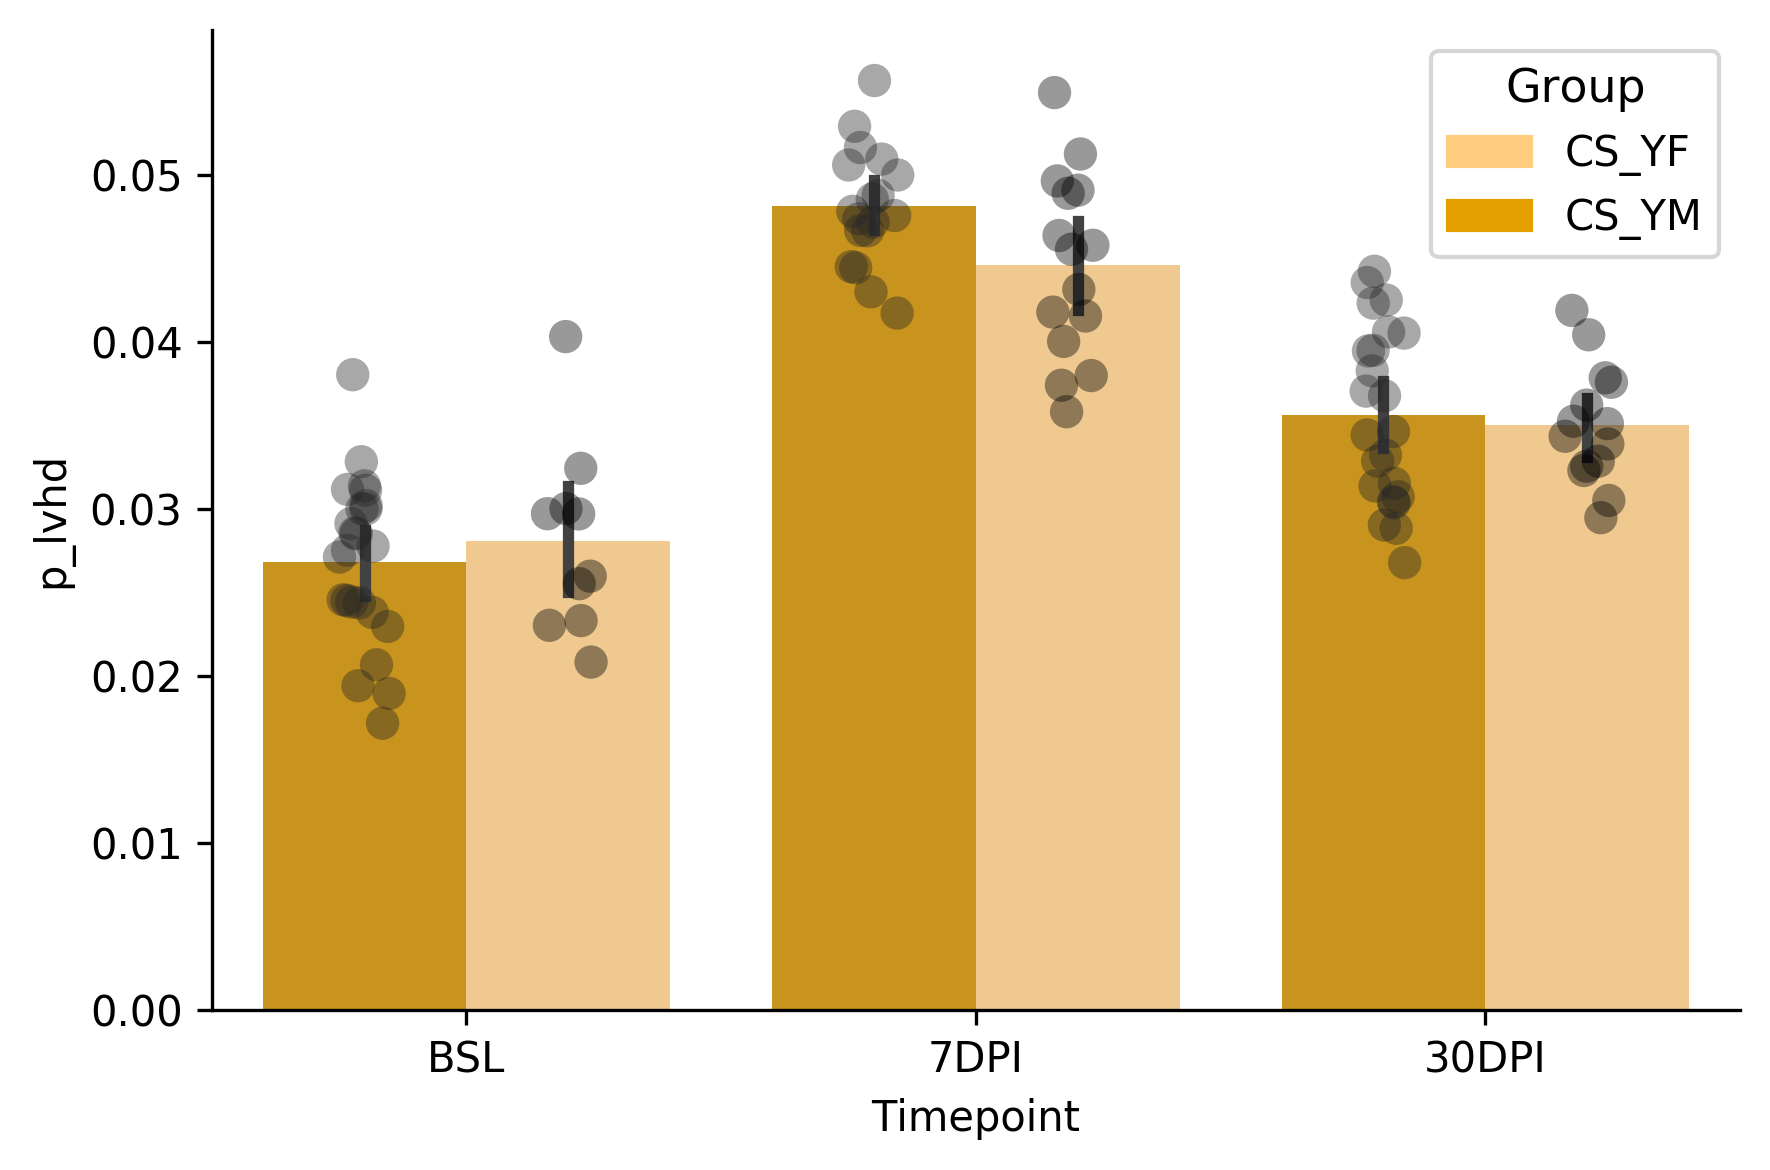

In [ ]:
from matplotlib.patches import Patch

fig, ax = plt.subplots()
fig.dpi = 300

sns.barplot(
    data=plot_df_clean,
    x='timepoint', y='p_lvhd', hue='group',
    palette=full_palette,
    order=timepoint_order,
    hue_order=['CS_YM', 'CS_YF'],
    capsize=0,
    ax=ax
)

sns.stripplot(
    data=plot_df_clean,
    x='timepoint', y='p_lvhd', hue='group',
    order=timepoint_order,
    hue_order=['CS_YM', 'CS_YF'],
    dodge=True,
    jitter=True,
    size=8,
    color='black',
    alpha=0.4,
    ax=ax
)

ax.set_xlabel('Timepoint')


present_groups = plot_df_young['group'].unique()
handles = [Patch(color=full_palette[g], label=g) for g in present_groups if g in full_palette]
ax.legend(handles=handles, title='Group', fontsize=10, title_fontsize=11)

sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(SAVE_PATH / 'CS_YM_YF_Motor_Deficit_Transition_Probability.pdf')
plt.show()

### now for aged CS

In [ ]:
plot_df_aged = plot_df[plot_df['age'] == 'aged']
plot_df_aged.shape

(76, 6)

In [ ]:
timepoint_order = ['BSL', '7DPI', '30DPI']
plot_df_aged['timepoint'] = pd.Categorical(plot_df_aged['timepoint'],categories=timepoint_order, ordered=True)
plot_df_aged = plot_df_aged.sort_values('timepoint')

/home/llorente/[/home/llorente/miniconda3new]/envs/moseq2-new/lib/python3.7/site-packages/ipykernel_launcher.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  


In [ ]:
plot_df_aged.columns

Index(['uuid', 'timepoint', 'sex', 'age', 'p_lvhd', 'group'], dtype='object')

In [ ]:
def remove_outliers_iqr(df, value_col, group_cols):
    """Remove outliers using 1.5×IQR rule within each group."""
    mask = pd.Series(True, index=df.index)
    for keys, grp in df.groupby(group_cols):
        Q1  = grp[value_col].quantile(0.25)
        Q3  = grp[value_col].quantile(0.75)
        IQR = Q3 - Q1
        lo, hi = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
        outlier_idx = grp[(grp[value_col] < lo) | (grp[value_col] > hi)].index
        mask[outlier_idx] = False
    return df[mask]

z = len(plot_df_aged)
print(f"Before: {z} rows")
plot_df_aged = remove_outliers_iqr(plot_df_aged, 'p_lvhd', ['group', 'timepoint'])
print(f"After:  {len(plot_df_aged)} rows")
print(f"Removed: {len(plot_df_aged) - z} outliers")

Before: 76 rows
After:  65 rows
Removed: -11 outliers


In [ ]:
plot_df_clean = plot_df_aged.copy()

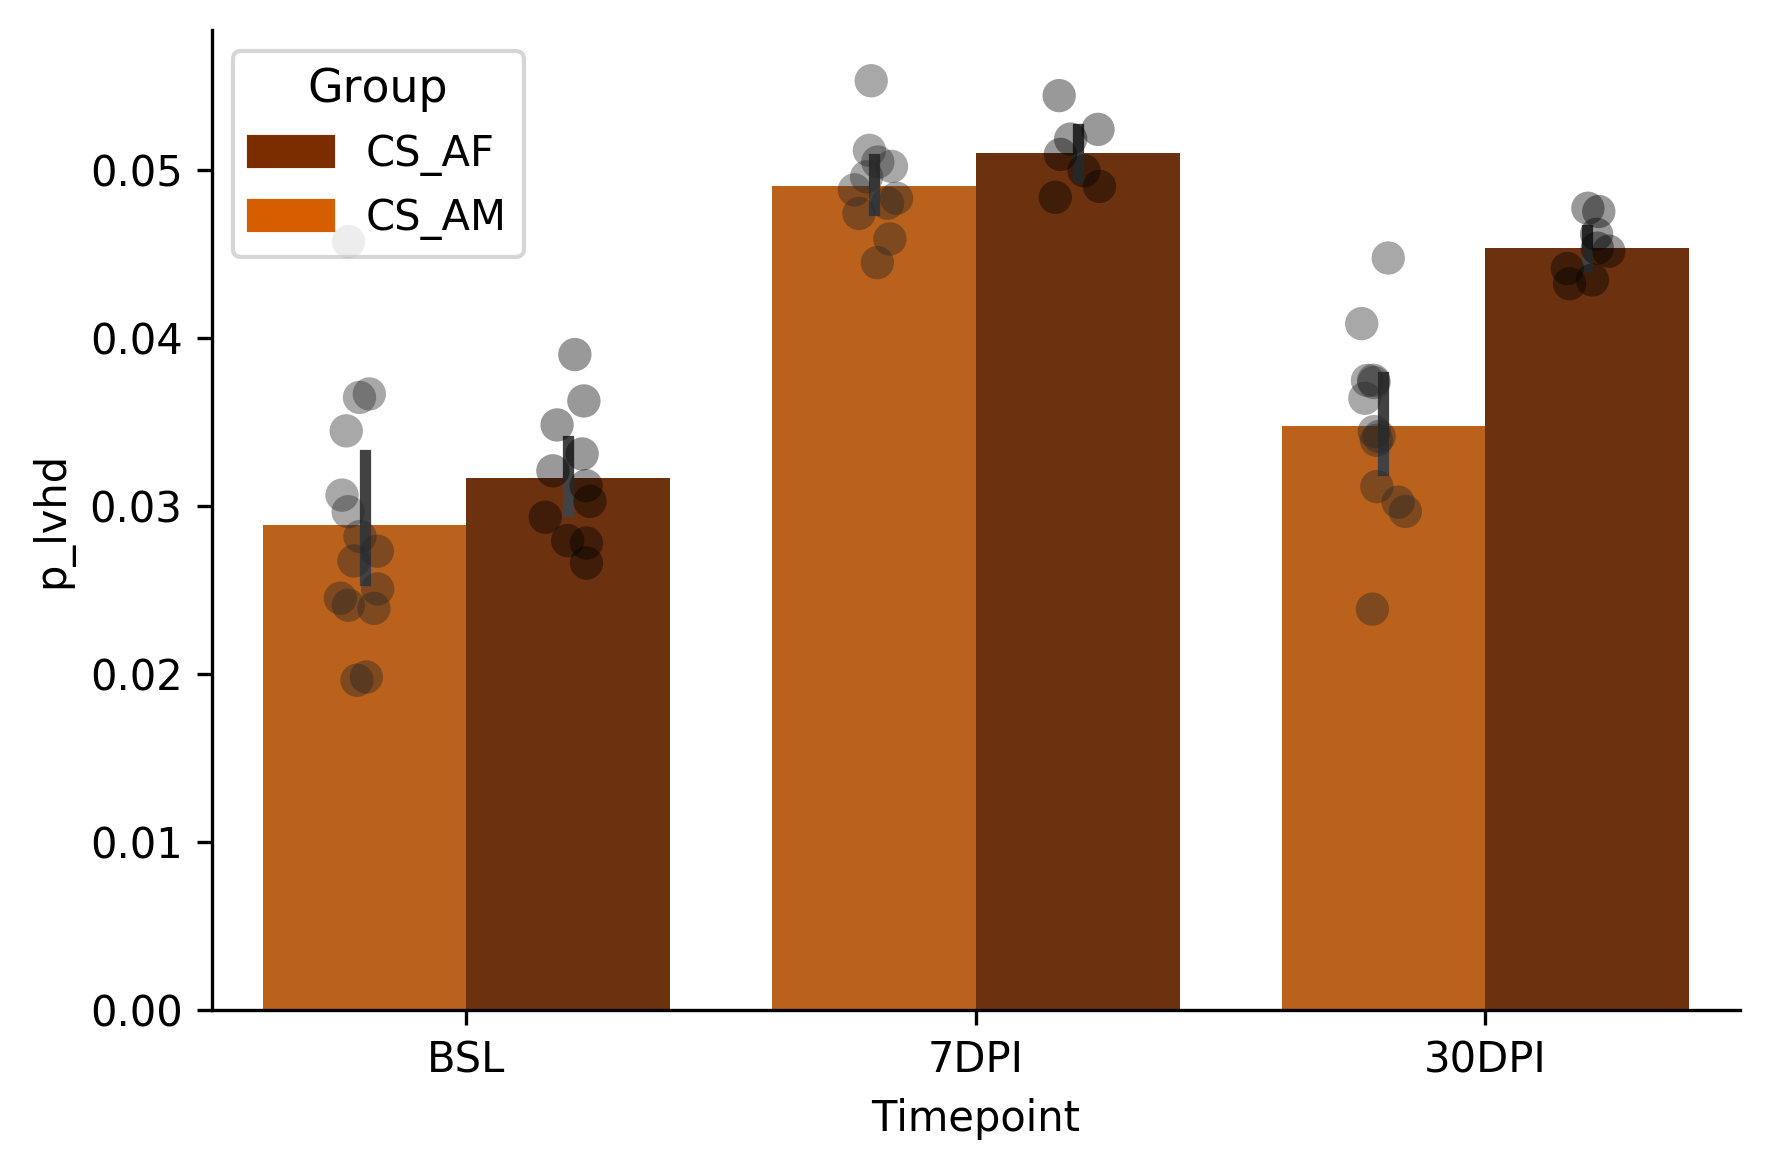

In [ ]:
from matplotlib.patches import Patch

fig, ax = plt.subplots()
fig.dpi = 300

sns.barplot(
    data=plot_df_clean,
    x='timepoint', y='p_lvhd', hue='group',
    palette=full_palette,
    order=timepoint_order,
    hue_order=['CS_AM', 'CS_AF'],
    capsize=0,
    ax=ax
)

sns.stripplot(
    data=plot_df_clean,
    x='timepoint', y='p_lvhd', hue='group',
    order=timepoint_order,
    hue_order=['CS_AM', 'CS_AF'],
    dodge=True,
    jitter=True,
    size=8,
    color='black',
    alpha=0.4,
    ax=ax
)

ax.set_xlabel('Timepoint')


present_groups = plot_df_clean['group'].unique()
handles = [Patch(color=full_palette[g], label=g) for g in present_groups if g in full_palette]
ax.legend(handles=handles, title='Group', fontsize=10, title_fontsize=11)

sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(SAVE_PATH / 'CS_AM_AF_Motor_Deficit_Transition_Probability.pdf')
plt.show()

## P(transitioning into cognitive deficit)

**Cognitive deficit proxy:** P(next syllable ∈ LVLD cluster) in WMS-treated mice. LVLD (Low Velocity, Low Displacement) syllables are associated with reduced exploratory behavior following WMS. Plotted separately for young and aged cohorts.

In [ ]:
lvld_syllables = [s for s, c in id_to_cluster.items() if c == 'Low Vel, Low Disp']
non_lvld_syllables = [s for s, c in id_to_cluster.items() if c != 'Low Vel, Low Disp']

print(f"Low Vel, Low Disp syllables: {sorted(lvld_syllables)}")
print(f"Non-Low Vel, Low Disp syllables (rows): {sorted(non_lvld_syllables)}")

Low Vel, Low Disp syllables: [2, 5, 11, 14, 24, 27, 30, 31, 33, 37]
Non-Low Vel, Low Disp syllables (rows): [0, 1, 3, 4, 6, 7, 8, 9, 10, 12, 13, 15, 16, 17, 18, 19, 20, 21, 22, 23, 25, 26, 28, 29, 32, 34, 35, 36]


In [ ]:
records = []

for uuid, T in mouse_transition_matrices.items():
    if uuid not in mouse_meta_df.index:
        continue
    meta = mouse_meta_df.loc[uuid]

    if meta['treatment'] != 'WMS':
        continue
    if meta['age'] not in ('young', 'aged'):
        continue
    if meta['sex'] not in ('Male', 'Female'):
        continue

    sub_matrix = T[np.ix_(non_lvld_syllables, lvld_syllables)]
    p_scalar   = sub_matrix.sum(axis=1).mean()

    # group = age_sex combination
    age_tag = 'Y' if meta['age'] == 'young' else 'A'
    sex_tag = 'M' if meta['sex'] == 'Male'  else 'F'
    group   = f'WMS_{age_tag}{sex_tag}'  # CS_YM, CS_YF, CS_AM, CS_AF

    records.append({
        'uuid':      uuid,
        'timepoint': meta['timepoint'],
        'sex':       meta['sex'],
        'age':       meta['age'],
        'p_lvld':    p_scalar,
        'group':     group,
    })

plot_df = pd.DataFrame(records)
print(plot_df.shape)
print(plot_df['group'].value_counts())
print(plot_df['timepoint'].value_counts())

(185, 6)
WMS_YM    65
WMS_AM    49
WMS_YF    43
WMS_AF    28
Name: group, dtype: int64
BSL      66
30DPI    60
7DPI     59
Name: timepoint, dtype: int64


### Plot young

In [ ]:
plot_df_young = plot_df[plot_df['age'] == 'young']
plot_df_young.shape

(108, 6)

In [ ]:
timepoint_order = ['BSL', '7DPI', '30DPI']
plot_df_young['timepoint'] = pd.Categorical(plot_df_young['timepoint'],categories=timepoint_order, ordered=True)
plot_df_young = plot_df_young.sort_values('timepoint')

/home/llorente/[/home/llorente/miniconda3new]/envs/moseq2-new/lib/python3.7/site-packages/ipykernel_launcher.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  


In [ ]:
plot_df_young.columns

Index(['uuid', 'timepoint', 'sex', 'age', 'p_lvld', 'group'], dtype='object')

In [ ]:
def remove_outliers_iqr(df, value_col, group_cols):
    """Remove outliers using 1.5×IQR rule within each group."""
    mask = pd.Series(True, index=df.index)
    for keys, grp in df.groupby(group_cols):
        Q1  = grp[value_col].quantile(0.25)
        Q3  = grp[value_col].quantile(0.75)
        IQR = Q3 - Q1
        lo, hi = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
        outlier_idx = grp[(grp[value_col] < lo) | (grp[value_col] > hi)].index
        mask[outlier_idx] = False
    return df[mask]

z = len(plot_df_young)
print(f"Before: {z} rows")
plot_df_young = remove_outliers_iqr(plot_df_young, 'p_lvld', ['group', 'timepoint'])
print(f"After:  {len(plot_df_young)} rows")
print(f"Removed: {z - len(plot_df_young) - } outliers")

Before: 108 rows
After:  103 rows
Removed: -5 outliers


In [ ]:
plot_df_clean = plot_df_young.copy()

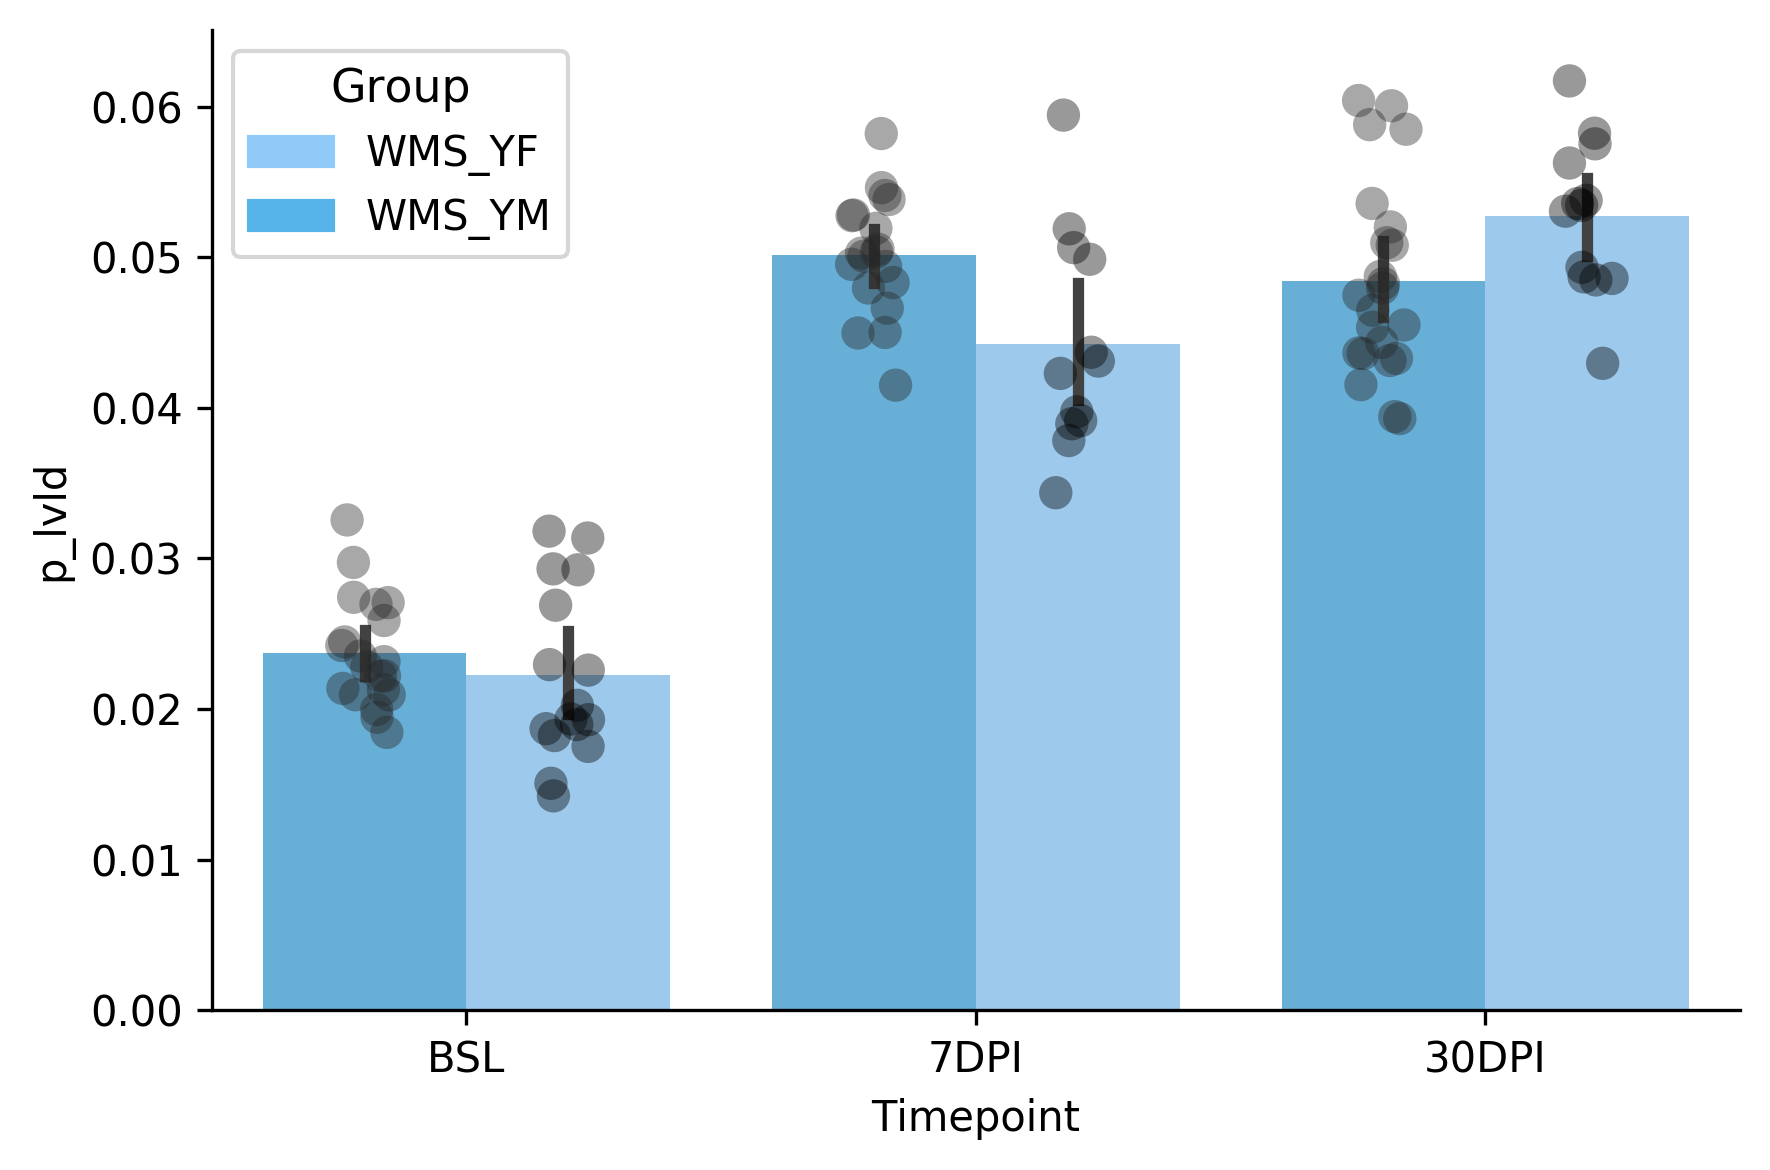

In [ ]:
from matplotlib.patches import Patch

fig, ax = plt.subplots()
fig.dpi = 300

sns.barplot(
    data=plot_df_clean,
    x='timepoint', y='p_lvld', hue='group',
    palette=full_palette,
    order=timepoint_order,
    hue_order=['WMS_YM', 'WMS_YF'],
    capsize=0,
    ax=ax
)

sns.stripplot(
    data=plot_df_clean,
    x='timepoint', y='p_lvld', hue='group',
    order=timepoint_order,
    hue_order=['WMS_YM', 'WMS_YF'],
    dodge=True,
    jitter=True,
    size=8,
    color='black',
    alpha=0.4,
    ax=ax
)

ax.set_xlabel('Timepoint')


present_groups = plot_df_clean['group'].unique()
handles = [Patch(color=full_palette[g], label=g) for g in present_groups if g in full_palette]
ax.legend(handles=handles, title='Group', fontsize=10, title_fontsize=11)

sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(SAVE_PATH / 'WMS_YM_YF_Cognitive_Deficit_Transition_Probability.pdf')
plt.show()

### now for aged WMS

In [ ]:
plot_df_aged = plot_df[plot_df['age'] == 'aged']
plot_df_aged.shape

(77, 6)

In [ ]:
plot_df_aged['age'].unique()

array(['aged'], dtype=object)

In [ ]:
timepoint_order = ['BSL', '7DPI', '30DPI']
plot_df_aged['timepoint'] = pd.Categorical(plot_df_aged['timepoint'],categories=timepoint_order, ordered=True)
plot_df_aged = plot_df_aged.sort_values('timepoint')

/home/llorente/[/home/llorente/miniconda3new]/envs/moseq2-new/lib/python3.7/site-packages/ipykernel_launcher.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  


In [ ]:
plot_df_aged.columns

Index(['uuid', 'timepoint', 'sex', 'age', 'p_lvld', 'group'], dtype='object')

In [ ]:
def remove_outliers_iqr(df, value_col, group_cols):
    """Remove outliers using 1.5×IQR rule within each group."""
    mask = pd.Series(True, index=df.index)
    for keys, grp in df.groupby(group_cols):
        Q1  = grp[value_col].quantile(0.25)
        Q3  = grp[value_col].quantile(0.75)
        IQR = Q3 - Q1
        lo, hi = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
        outlier_idx = grp[(grp[value_col] < lo) | (grp[value_col] > hi)].index
        mask[outlier_idx] = False
    return df[mask]

z = len(plot_df_aged)
print(f"Before: {z} rows")
plot_df_aged = remove_outliers_iqr(plot_df_aged, 'p_lvld', ['group', 'timepoint'])
print(f"After:  {len(plot_df_aged)} rows")
print(f"Removed: {len(plot_df_aged) - z} outliers")

Before: 77 rows
After:  70 rows
Removed: -7 outliers


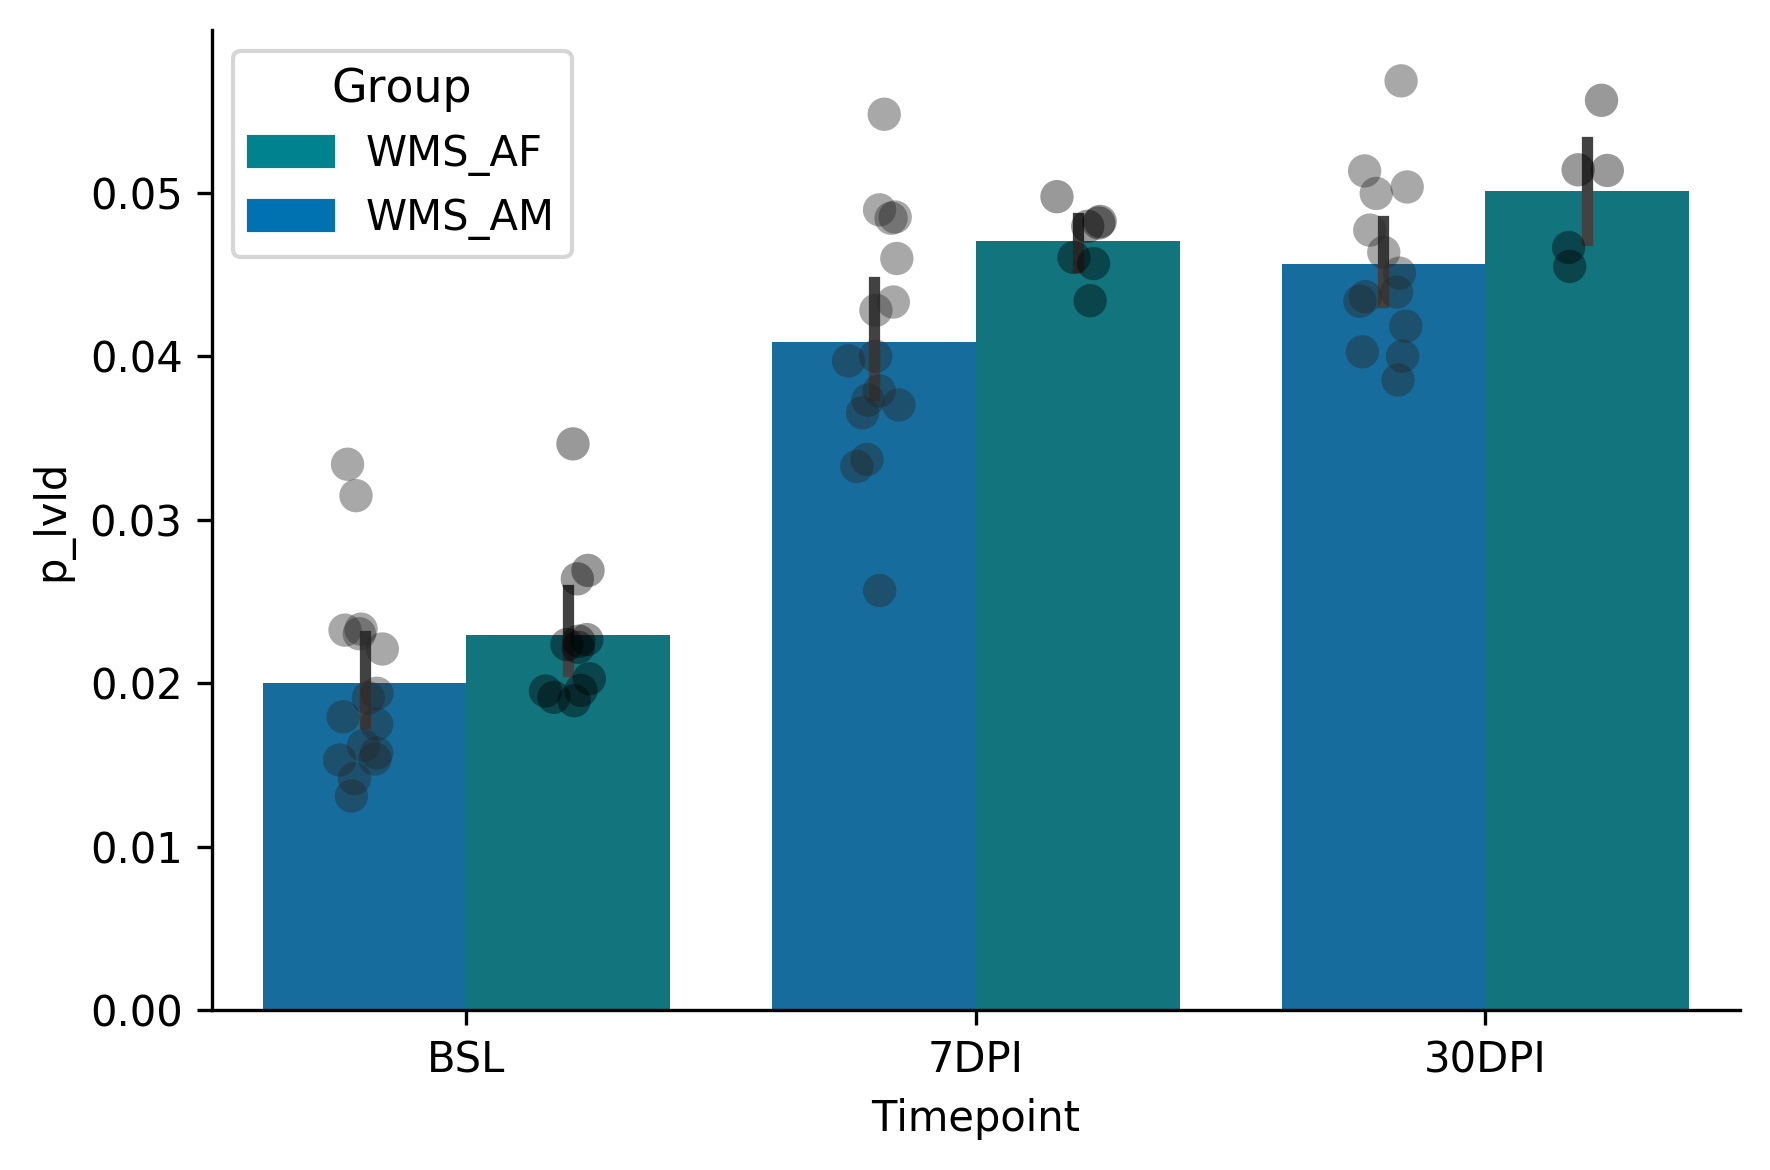

In [ ]:
from matplotlib.patches import Patch

fig, ax = plt.subplots()
fig.dpi = 300

sns.barplot(
    data=plot_df_clean,
    x='timepoint', y='p_lvld', hue='group',
    palette=full_palette,
    order=timepoint_order,
    hue_order=['WMS_AM', 'WMS_AF'],
    capsize=0,
    ax=ax
)

sns.stripplot(
    data=plot_df_clean,
    x='timepoint', y='p_lvld', hue='group',
    order=timepoint_order,
    hue_order=['WMS_AM', 'WMS_AF'],
    dodge=True,
    jitter=True,
    size=8,
    color='black',
    alpha=0.4,
    ax=ax
)

ax.set_xlabel('Timepoint')

present_groups = plot_df_aged['group'].unique()
handles = [Patch(color=full_palette[g], label=g) for g in present_groups if g in full_palette]
ax.legend(handles=handles, title='Group', fontsize=10, title_fontsize=11)

sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(SAVE_PATH / 'WMS_AM_AF_Cognitive_Deficit_Transition_Probability.pdf')
plt.show()

In [ ]:
plot_df_aged['group'].unique()

array(['WMS_AF', 'WMS_AM'], dtype=object)